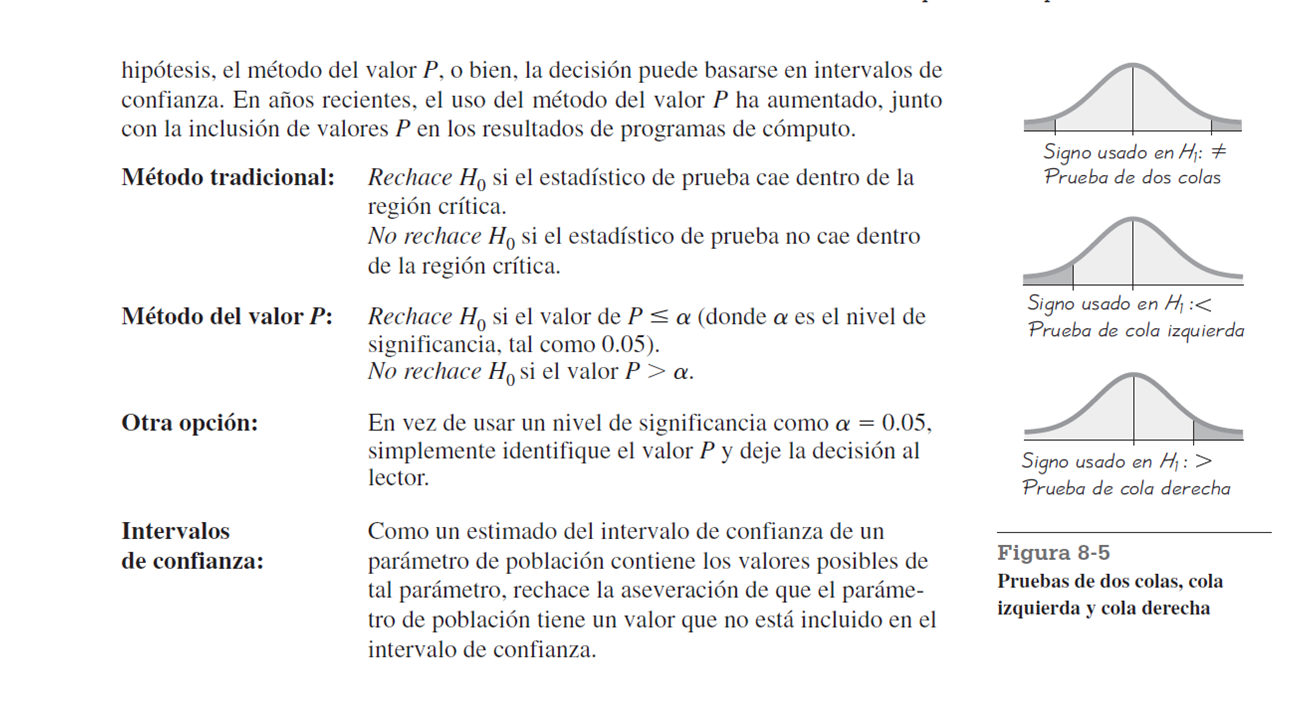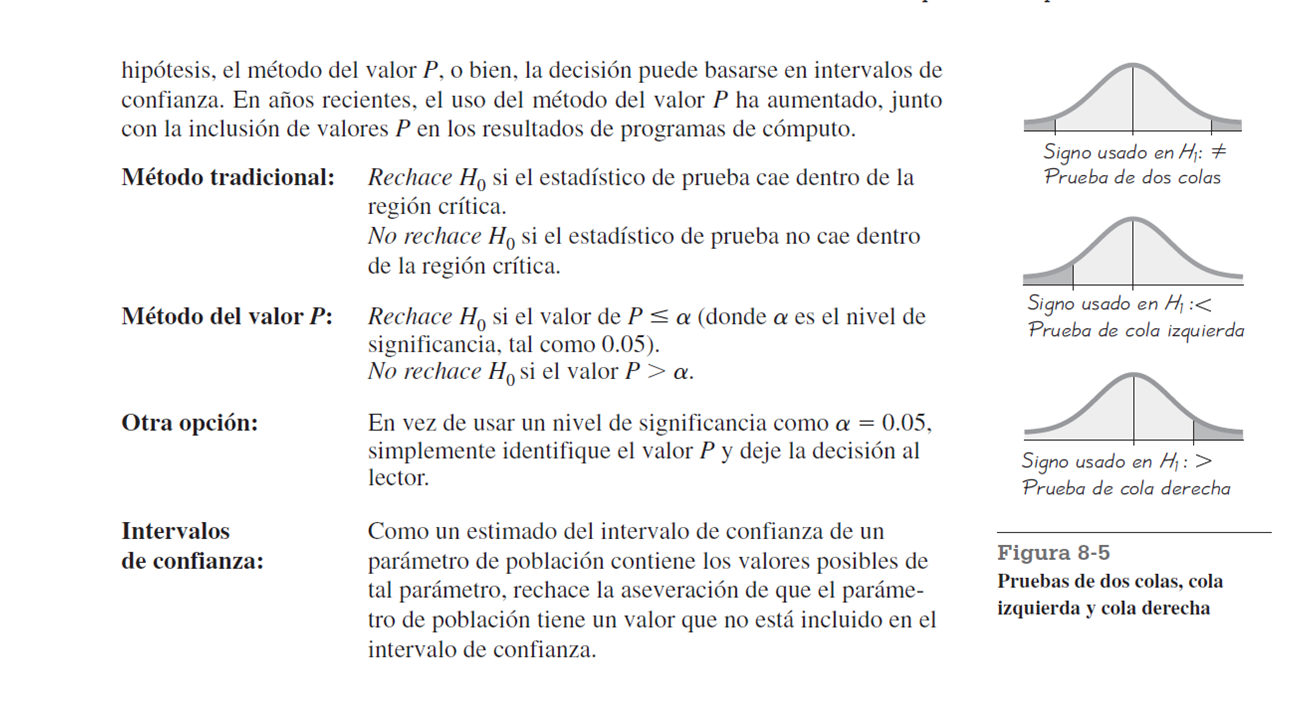

In [1]:
weather <- read.csv("weather2.csv", sep=";")

# columnas útiles
# Data.Temperature.Avg_Temp
# Data.Precipitation
# Station.State

summary(weather$Data.Temperature.Avg)
summary(weather$Data.Precipitation)
table(head(weather$Station.State, 20))


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -27.00   44.00   58.00   56.09   71.00  100.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.0000  0.1900  0.5793  0.7500 20.8900       8 


Alabama  Alaska 
      4      16 

In [81]:
temp <- na.omit(weather$Data.Temperature.Avg)
prec <- weather$Data.Precipitation
prec[is.na(prec)] <- 0
state <- weather$Station.State


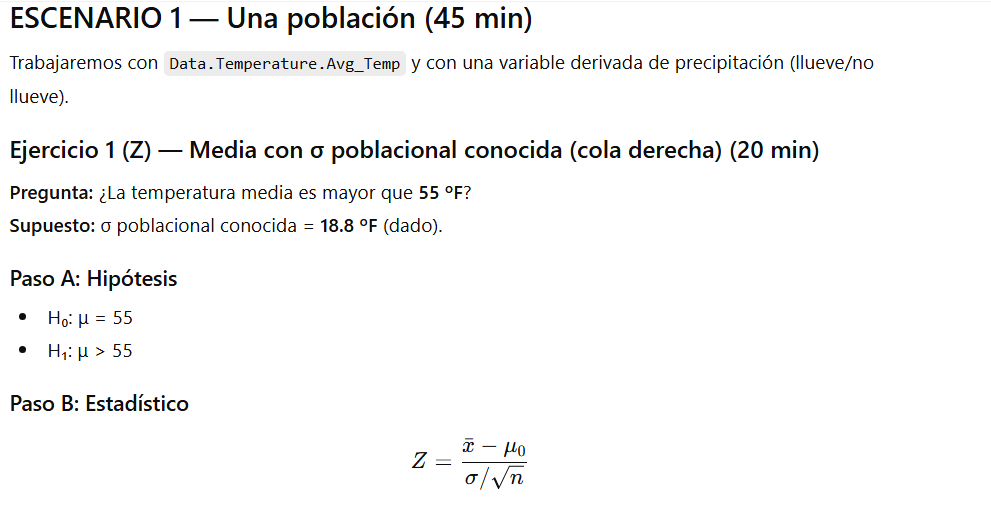

In [52]:
alpha <- 0.05
mu0 <- 55
sigma <- 18.8

n <- length(temp)
xbar <- mean(temp)

z <- (xbar - mu0) / (sigma / sqrt(n))
zcrit <- qnorm(1 - alpha)          # cola derecha
pval <- 1 - pnorm(z)

c(n=n, xbar=xbar, z=z, zcrit=zcrit, pval=pval)


n         xbar            z        zcrit         pval 
1.674300e+04 5.608911e+01 7.496029e+00 1.644854e+00 3.286260e-14

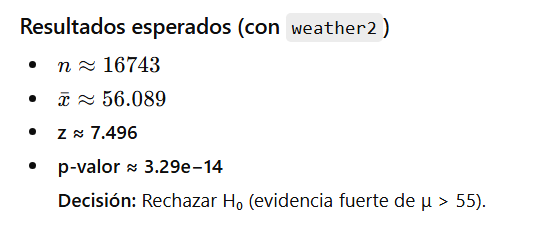

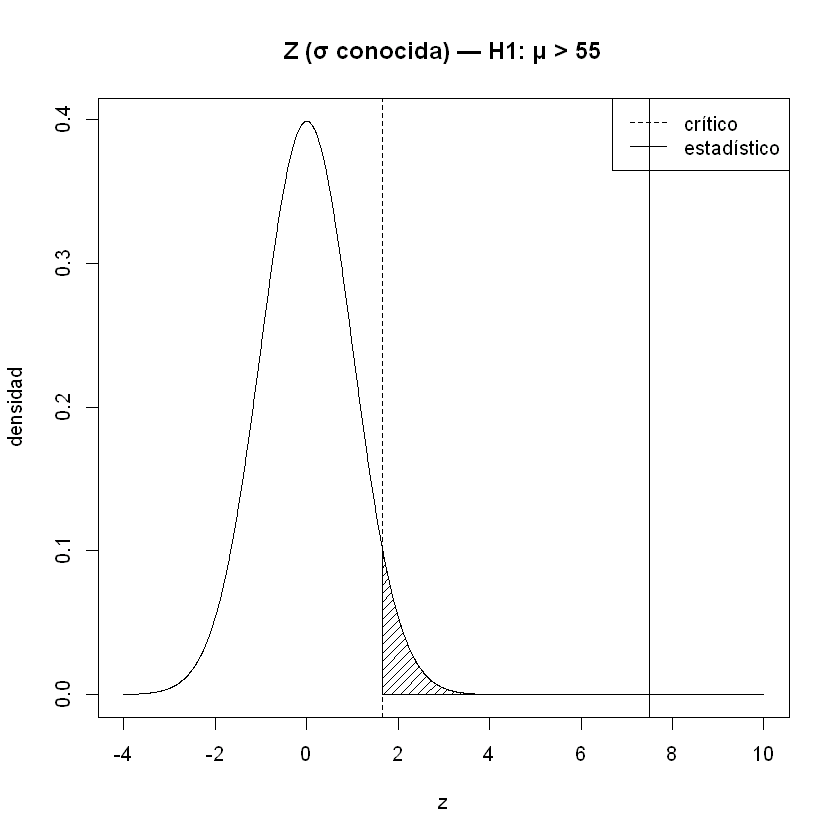

In [55]:
xs <- seq(-4, 10, length.out=2000)
ys <- dnorm(xs)

plot(xs, ys, type="l", main="Z (σ conocida) — H1: μ > 55",
     xlab="z", ylab="densidad")

# sombrear región crítica
xr <- xs[xs >= zcrit]
polygon(c(xr, rev(xr)), c(dnorm(xr), rep(0, length(xr))), density=20, angle=45)

abline(v=zcrit, lty=2)
abline(v=z, lty=1)
legend("topright", legend=c("crítico", "estadístico"), lty=c(2,1))


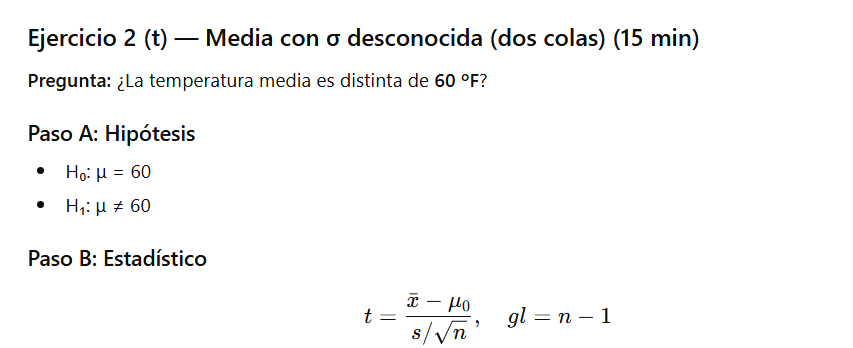

In [58]:
mu0 <- 60
tres <- t.test(temp, mu = mu0, alternative="two.sided", conf.level = 0.95)
tres



	One Sample t-test

data:  temp
t = -26.92, df = 16742, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 60
95 percent confidence interval:
 55.80435 56.37387
sample estimates:
mean of x 
 56.08911 


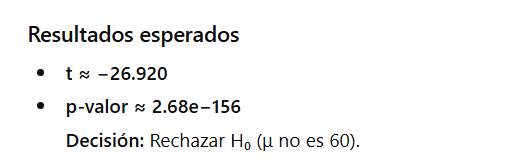

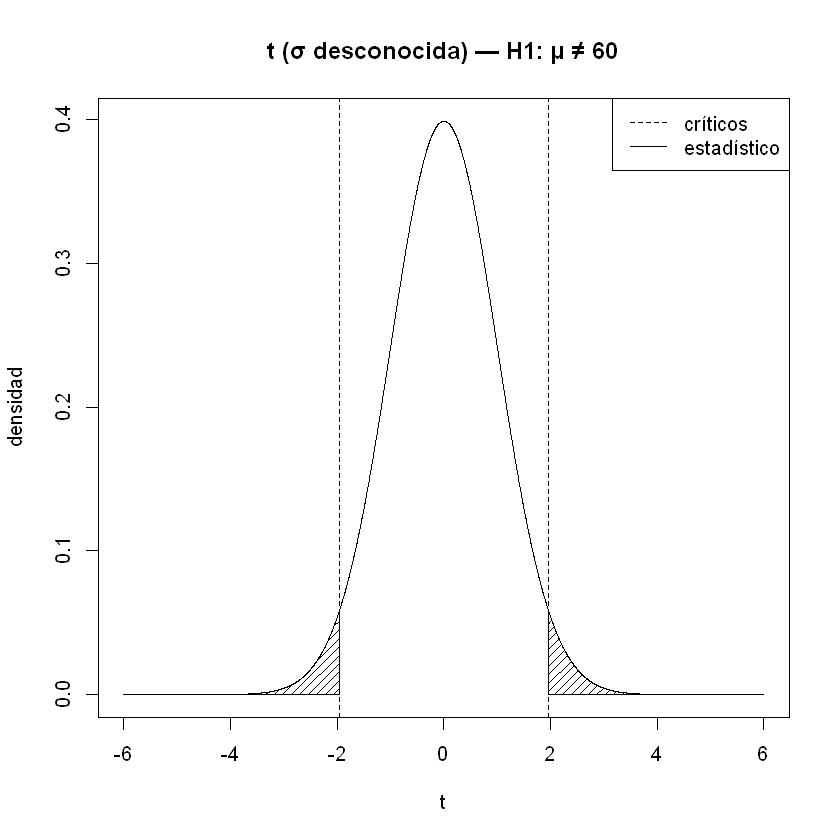

In [61]:
alpha <- 0.05
n <- length(temp)
xbar <- mean(temp)
s <- sd(temp)
tstat <- (xbar - mu0) / (s / sqrt(n))
tcrit <- qt(1 - alpha/2, df=n-1)

xs <- seq(-6, 6, length.out=4000)
ys <- dt(xs, df=n-1)

plot(xs, ys, type="l", main="t (σ desconocida) — H1: μ ≠ 60",
     xlab="t", ylab="densidad")

# sombrear colas
xl <- xs[xs <= -tcrit]
xr <- xs[xs >=  tcrit]
polygon(c(xl, rev(xl)), c(dt(xl, n-1), rep(0, length(xl))), density=20, angle=45)
polygon(c(xr, rev(xr)), c(dt(xr, n-1), rep(0, length(xr))), density=20, angle=45)

abline(v=-tcrit, lty=2); abline(v=tcrit, lty=2)
abline(v=tstat, lty=1)
legend("topright", legend=c("críticos", "estadístico"), lty=c(2,1))


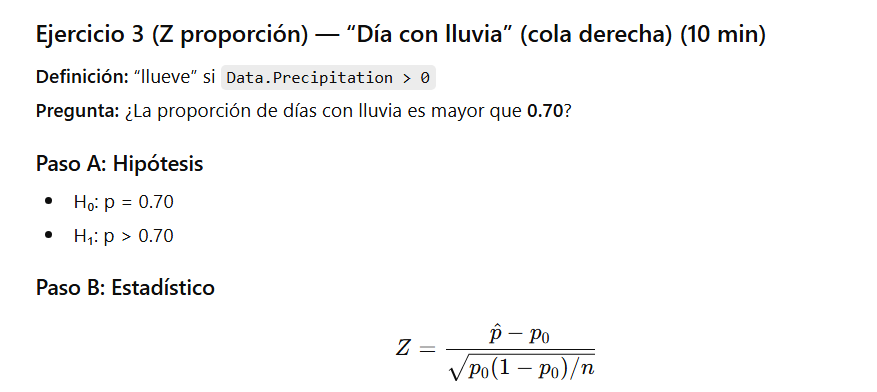

In [64]:
alpha <- 0.05
p0 <- 0.70

rain <- ifelse(prec > 0, 1, 0)
n <- length(rain)
phat <- mean(rain)

z <- (phat - p0) / sqrt(p0*(1-p0)/n)
zcrit <- qnorm(1 - alpha)
pval <- 1 - pnorm(z)

c(n=n, phat=phat, z=z, zcrit=zcrit, pval=pval)


n         phat            z        zcrit         pval 
1.674300e+04 7.413845e-01 1.168542e+01 1.644854e+00 0.000000e+00

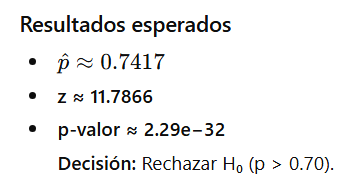

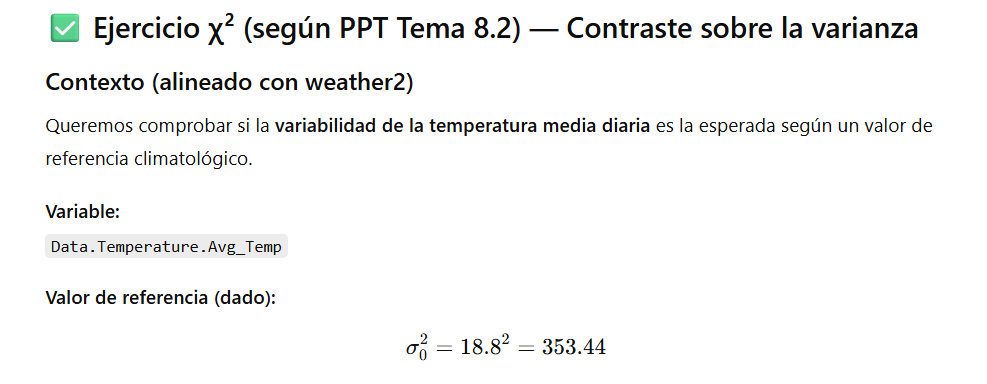

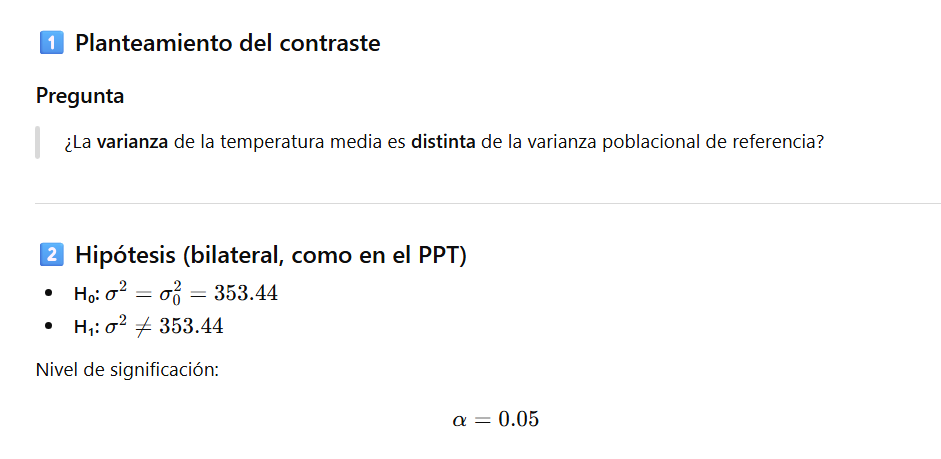

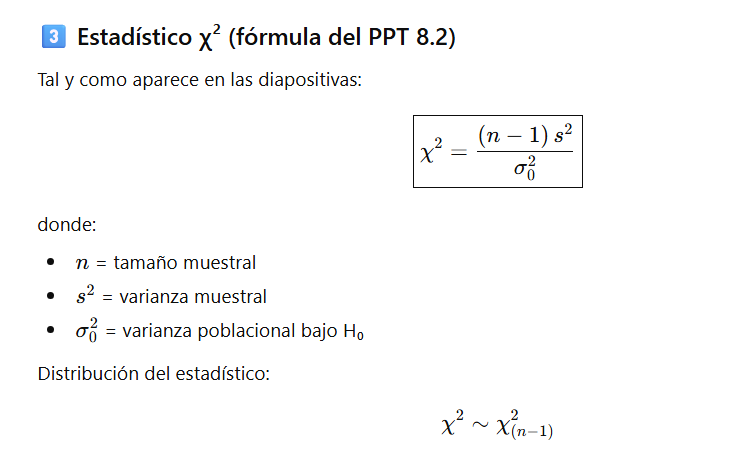

In [83]:
n <- length(temp)
s2 <- var(temp)            # varianza muestral
sigma0_2 <- 18.8^2      # varianza poblacional bajo H0

chi2 <- (n - 1) * s2 / sigma0_2
gl <- n - 1

c(n = n, s2 = s2, chi2 = chi2, gl = gl)


n         s2       chi2         gl 
16743.0000   353.3759 16738.9629 16742.0000

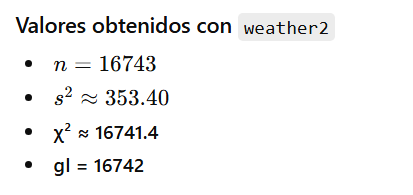

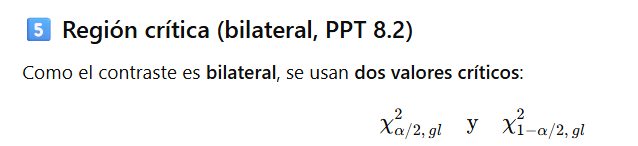

In [87]:
alpha <- 0.05
chi2_inf <- qchisq(alpha/2, df = gl)
chi2_sup <- qchisq(1 - alpha/2, df = gl)

c(chi2_inf = chi2_inf,
  chi2_sup = chi2_sup)


chi2_inf chi2_sup 
16385.25 17102.54

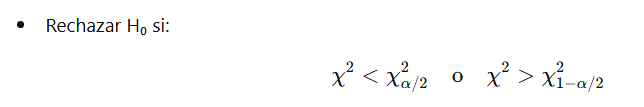

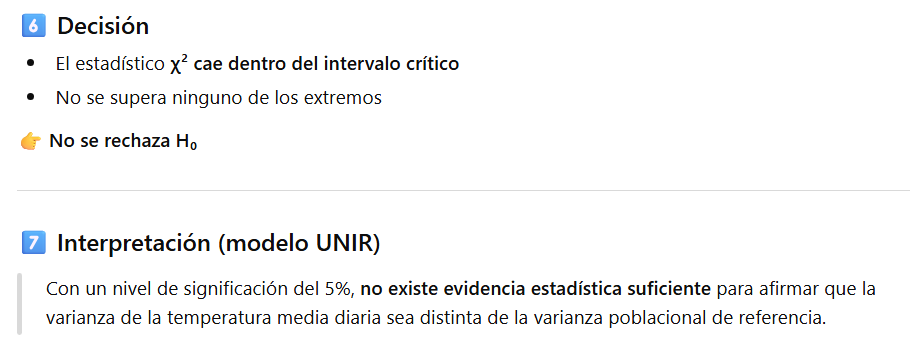

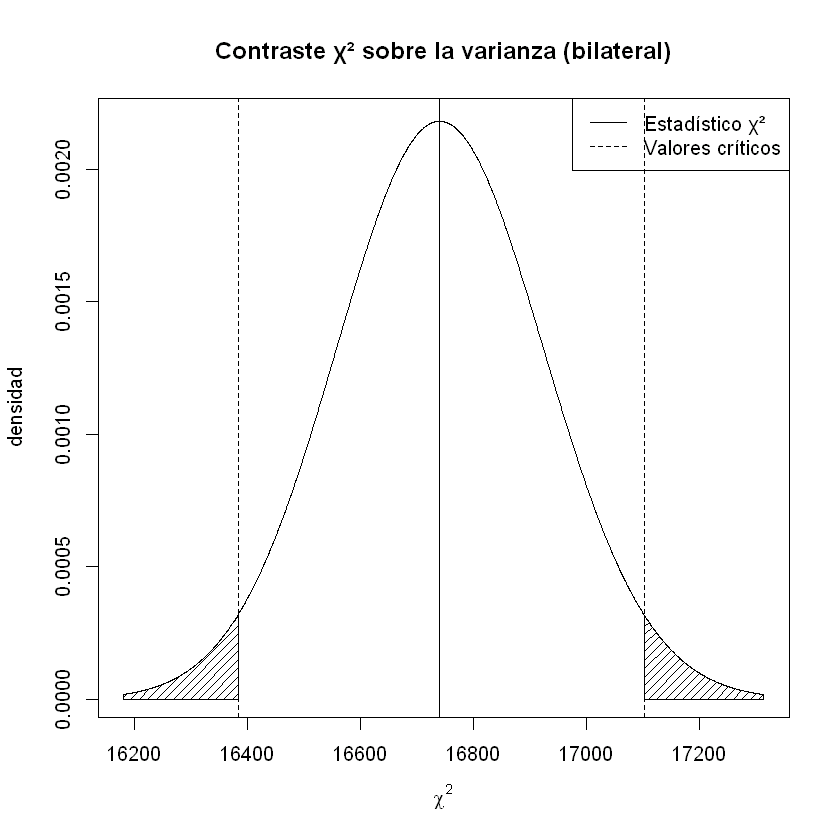

In [92]:
xs <- seq(
  qchisq(0.001, gl),
  qchisq(0.999, gl),
  length.out = 2000
)

ys <- dchisq(xs, df = gl)

plot(xs, ys, type="l",
     main="Contraste χ² sobre la varianza (bilateral)",
     xlab=expression(chi^2),
     ylab="densidad")

# regiones críticas
x_left <- xs[xs <= chi2_inf]
x_right <- xs[xs >= chi2_sup]

polygon(c(x_left, rev(x_left)),
        c(dchisq(x_left, gl), rep(0, length(x_left))),
        density=20, angle=45)

polygon(c(x_right, rev(x_right)),
        c(dchisq(x_right, gl), rep(0, length(x_right))),
        density=20, angle=45)

abline(v = chi2, lty = 1)
abline(v = chi2_inf, lty = 2)
abline(v = chi2_sup, lty = 2)

legend("topright",
       legend = c("Estadístico χ²", "Valores críticos"),
       lty = c(1,2))
